## European Aviation Market Analysis (PCA & MDS)

Analyzed aviation data (2013–2024) using PCA and MDS to identify market structure and dynamics
Revealed a highly synchronized EU aviation system driven by a dominant common factor
Identified COVID-19 as a structural break and quantified post-pandemic recovery patterns
Compared EU vs non-EU markets, highlighting differences in integration, stability, and risk

## source
The data are sourced from the Eurostat database, the official statistical database maintained by the European Statistical Office (Eurostat). It provides comprehensive statistics covering multiple domains, including the economy, society, population, employment, education, health, and the environment. The data in this database are highly standardized and comparable across countries, covering all EU Member States as well as several related countries, and are regularly updated. As a result, Eurostat data are widely used in academic research and policy analysis.

https://ec.europa.eu/eurostat/web/main/data/database

Within the Traffic subdirectory, information on air transport activity for EU Member States and other European countries from 2015 to 2024 can be found. These data are used in this study to analyze annual changes in the aviation industry across EU countries.

In [44]:
import pandas as pd

aireu = pd.read_csv("pass.csv")

print(aireu.head())

  freq,unit,tra_meas,tra_cov,schedule,geo\TIME_PERIOD      2013       2014   \
0                         A,PAS,PAS_CRD,TOTAL,TOT,AT   25749724   26378676    
1                         A,PAS,PAS_CRD,TOTAL,TOT,BA          :          :    
2                         A,PAS,PAS_CRD,TOTAL,TOT,BE   26389927   28776258    
3                         A,PAS,PAS_CRD,TOTAL,TOT,BG    7079292    7520697    
4                         A,PAS,PAS_CRD,TOTAL,TOT,CH   44217568   46127426    

       2015       2016       2017       2018       2019       2020   \
0  26754007   27181511   28327279   31138417   35644188    9168431    
1         :          :          :          :          :          :    
2  30958841   30115832   33260493   34506309   35385188    9465828    
3   7610949    9324217   11092651   12137714   11713068    3729017    
4  48026375   50505492   53564943   56139549   57194328   16006811    

       2021       2022       2023       2024   
0  11105564   26381180   33063166   35281811   
1 

In [36]:
import numpy as np


aireu.columns = aireu.columns.str.strip()
print(aireu.columns.tolist())

year_cols = [c for c in aireu.columns if c.isdigit()]
print(year_cols)

aireu[year_cols] = aireu[year_cols].apply(pd.to_numeric, errors="coerce")

print(aireu[year_cols].describe())

['freq,unit,tra_meas,tra_cov,schedule,geo\\TIME_PERIOD', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
['2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
               2013          2014          2015          2016          2017  \
count  3.200000e+01  3.200000e+01  3.300000e+01  3.500000e+01  3.500000e+01   
mean   6.231006e+07  6.532075e+07  6.669044e+07  6.725302e+07  7.253452e+07   
std    1.366600e+08  1.429014e+08  1.479796e+08  1.534500e+08  1.649249e+08   
min    1.265766e+06  1.307128e+06  1.436003e+06  1.404152e+06  1.682133e+06   
25%    5.487400e+06  5.806168e+06  5.145856e+06  5.232303e+06  6.042792e+06   
50%    2.393906e+07  2.601262e+07  2.675401e+07  1.809995e+07  2.005495e+07   
75%    3.856916e+07  4.087023e+07  4.209640e+07  4.323671e+07  4.892189e+07   
max    7.461004e+08  7.812026e+08  8.196989e+08  8.716958e+08  9.388545e+08   

               2018          2019     

Column name normalization is a critical preprocessing step, as hidden formatting issues (such as trailing spaces) can silently break feature selection and lead to incorrect analytical results.

In [37]:
air_mat = aireu[year_cols].values

air_time = air_mat.T

countries = aireu.iloc[:, 0].astype(str)
countries = countries.str.split(",").str[-1].str.strip()

import pandas as pd
air_time = pd.DataFrame(air_time, columns=countries)

print(air_time.head())
print(air_time.shape)

freq,unit,tra_meas,tra_cov,schedule,geo\TIME_PERIOD          AT  BA  \
0                                                    25749724.0 NaN   
1                                                    26378676.0 NaN   
2                                                    26754007.0 NaN   
3                                                    27181511.0 NaN   
4                                                    28327279.0 NaN   

freq,unit,tra_meas,tra_cov,schedule,geo\TIME_PERIOD          BE          BG  \
0                                                    26389927.0   7079292.0   
1                                                    28776258.0   7520697.0   
2                                                    30958841.0   7610949.0   
3                                                    30115832.0   9324217.0   
4                                                    33260493.0  11092651.0   

freq,unit,tra_meas,tra_cov,schedule,geo\TIME_PERIOD          CH          CY  \
0                  

The data is restructured into a time-based matrix, where each row represents a year and each column represents a country. This transformation shifts the analysis from cross-sectional comparison to temporal evolution, which is more relevant for identifying market cycles.

In [38]:
col_var = air_time.var(axis=0)

zero_var_cols = col_var[col_var == 0].index

print("Zero variance countries:", list(zero_var_cols))

air_time = air_time.drop(columns=zero_var_cols)

Zero variance countries: []


Countries with no variation over time are removed because they do not contribute to identifying market dynamics. Including them would only add noise and reduce model efficiency.

BUT in fact there is no such kind of country which is not influenced by the COVID-19, indicating that the COVID is a world range shock.

In [39]:
air_time = air_time.apply(lambda x: x.fillna(x.mean()), axis=0)


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
air_scaled = scaler.fit_transform(air_time)

print(air_scaled.shape)

(12, 37)


Missing values are imputed to maintain continuity, while standardization ensures that large markets do not dominate the analysis due to scale differences.

In [40]:
from sklearn.decomposition import PCA

pca = PCA()
pca_air = pca.fit(air_scaled)

explained = pca.explained_variance_ratio_
print("Explained variance:", explained)
print("Cumulative:", explained.cumsum())

Explained variance: [8.30013634e-01 7.30843756e-02 4.14163417e-02 3.39873799e-02
 1.28786956e-02 4.40151473e-03 2.20104665e-03 9.41097213e-04
 7.03927083e-04 2.49440159e-04 1.22547825e-04 1.54761043e-33]
Cumulative: [0.83001363 0.90309801 0.94451435 0.97850173 0.99138043 0.99578194
 0.99798299 0.99892408 0.99962801 0.99987745 1.         1.        ]


## PCA analysis
We then conducted principal component analysis (PCA) on the standardized data. The results show that the first principal component (PC1) explains approximately 83.0% of the total variance, indicating that the vast majority of the information in the data can be summarized by a dominant common pattern of variation. The second principal component (PC2) explains an additional 7.3% of the variance, and together the first two principal components account for about 90.3% of the total variance. This suggests that most of the information in the original data can be retained using only two principal components.

The remaining principal components contribute very little additional variance, implying that their marginal role in explaining the data structure is limited. After dimensionality reduction, the data exhibit strong correlations and a substantially reduced dimensionality, indicating that PCA achieves an effective reduction. Overall, retaining the first two principal components allows for efficient dimensionality reduction without significant loss of information.

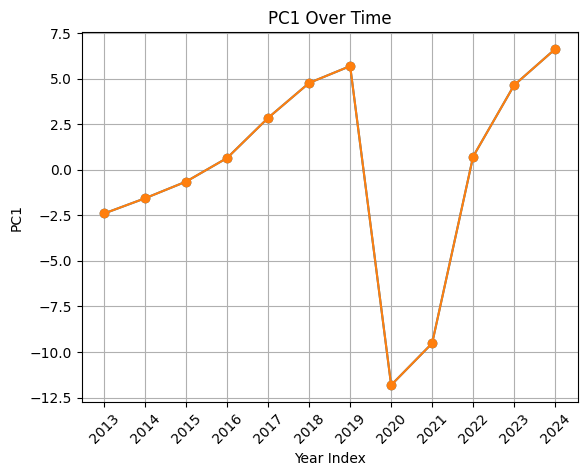

In [41]:
scores = pca.transform(air_scaled)

import matplotlib.pyplot as plt

plt.plot(scores[:, 0], marker='o')
plt.title("PC1 (Market Cycle)")
plt.xlabel("Year Index")
plt.ylabel("PC1")
plt.grid()
years = year_cols

plt.plot(years, scores[:, 0], marker='o')
plt.xticks(rotation=45)
plt.title("PC1 Over Time")
plt.show()

This figure does not represent a simple linear pattern of “growth–decline–recovery,” but rather a clearly segmented industry cycle with distinct structural phases. From 2013 to 2016, PC1 rises gradually from negative values toward zero, indicating a post-crisis recovery phase in which aviation demand improves steadily but without strong momentum. Between 2016 and 2019, the trend shifts into a phase of accelerated expansion, with PC1 increasing sharply and reaching a peak in 2019, reflecting strong demand growth driven by low-cost carrier expansion, increased mobility, and deeper integration within the EU aviation market. However, the transition from 2019 to 2020 shows a dramatic collapse, with PC1 dropping from a high positive value to an extreme negative level. This is not a normal cyclical downturn, but a structural break caused by an external shock (COVID-19), indicating a near-complete disruption of aviation activity. From 2021 to 2024, PC1 rebounds rapidly and even surpasses pre-pandemic levels, suggesting strong resilience in the system. Importantly, this recovery is not a simple return to trend but rather a compensatory rebound driven by the release of pent-up demand, policy support, and the restoration of connectivity. From a business perspective, the figure highlights a system characterized by synchronized cycles and systemic risk: under normal conditions, national aviation markets move together as part of an integrated system, while external shocks propagate across all countries simultaneously; however, the same level of integration also supports a rapid and coordinated recovery.

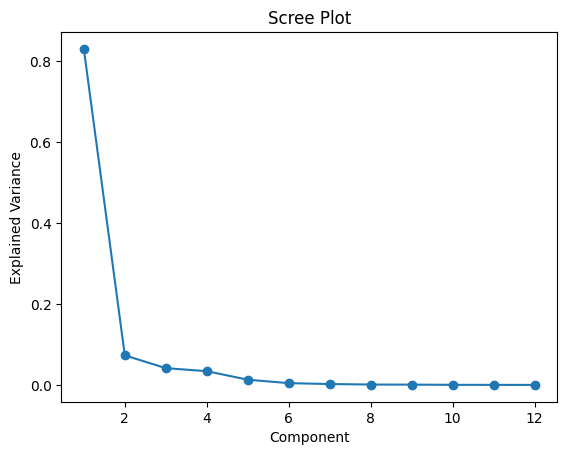

In [42]:
plt.plot(range(1, len(explained)+1), explained, marker='o')
plt.title("Scree Plot")
plt.xlabel("Component")
plt.ylabel("Explained Variance")
plt.show()

## visusalisation of quality
This scree plot reveals an extremely concentrated variance structure in the data, with the first principal component (PC1) explaining more than 80% of the total variance, while the contribution of all subsequent components drops sharply and becomes marginal. The steep decline from PC1 to PC2 indicates the presence of a dominant underlying factor that captures the vast majority of the variation across countries and over time. From the second component onward, the curve quickly flattens, suggesting diminishing returns in explanatory power and limited additional structural information. This pattern implies that the European aviation market is largely driven by a single systemic force rather than multiple independent dimensions. From a business perspective, this is a strong indication of high market integration: aviation activity across countries is not fragmented but highly synchronized, responding collectively to common macroeconomic conditions and external shocks. As a result, reducing the data to one or two principal components is sufficient to capture the core structure, enabling simpler and more interpretable strategic analysis without significant loss of information.


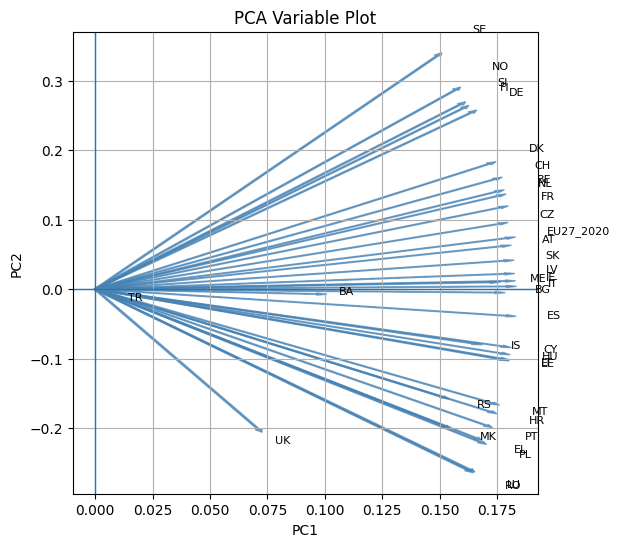

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))


for i, var in enumerate(air_time.columns):
    plt.arrow(0, 0,
              pca.components_[0, i],
              pca.components_[1, i],
              color='steelblue',
              alpha=0.7)
    
    plt.text(pca.components_[0, i]*1.1,
             pca.components_[1, i]*1.1,
             var,
             fontsize=8)


plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Variable Plot")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.grid()

plt.show()

This plot conveys two key points. First, most countries’ vectors are strongly aligned in the positive direction of PC1, indicating that the European aviation market is driven by a common systemic factor and exhibits a high degree of synchronization—effectively functioning as an integrated market. Second, a small number of countries (such as Turkey and Bosnia and Herzegovina) are located closer to the origin and contribute less to the principal components. These are mainly non-EU or peripheral countries that do not fully share the EU’s unified market structure and policy framework, resulting in weaker linkage with the overall market dynamics. From a business perspective, this implies that the core EU aviation market can be analyzed as a single system, while non-EU markets require separate evaluation due to higher uncertainty and lower integration.


In [ ]:

vars_names = air_time.columns.tolist()

# loadings（= rotation）
loadings = pd.DataFrame(
    pca.components_.T,
    index=vars_names,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])]
)

# PC1
loading_PC1 = loadings["PC1"]
abs_loading_PC1 = loading_PC1.abs()

PC1_ranked_vars = abs_loading_PC1.sort_values(ascending=False).index

print("PCA 1 Loading:")
print(loadings.loc[PC1_ranked_vars, "PC1"])

PCA 1 Loading:
IT           0.179110
ES           0.178997
EU27_2020    0.178963
IE           0.178635
LV           0.178299
SK           0.178170
CY           0.177260
AT           0.177040
HU           0.176829
EE           0.176498
LT           0.176321
FR           0.176270
CZ           0.175910
NL           0.175439
BE           0.174701
BG           0.174164
CH           0.173985
MT           0.172869
ME           0.172039
HR           0.171902
DK           0.171515
PT           0.170115
PL           0.167721
EL           0.165718
IS           0.164585
DE           0.163758
LU           0.163004
RO           0.162210
FI           0.160349
SI           0.159086
NO           0.157008
MK           0.152120
RS           0.151121
SE           0.149136
BA           0.096499
UK           0.071201
TR           0.013167
Name: PC1, dtype: float64


In [49]:
# PC2
loading_PC2 = loadings["PC2"]
abs_loading_PC2 = loading_PC2.abs()

PC2_ranked_vars = abs_loading_PC2.sort_values(ascending=False).index

print("PCA 2 Loading:")
print(loadings.loc[PC2_ranked_vars, "PC2"])

PCA 2 Loading:
SE           0.336125
NO           0.286922
SI           0.265922
FI           0.260569
RO          -0.260350
LU          -0.259388
DE           0.254020
PL          -0.219925
EL          -0.214025
UK          -0.201730
MK          -0.196941
PT          -0.195900
DK           0.180240
HR          -0.176146
MT          -0.163942
CH           0.158120
RS          -0.154970
BE           0.140181
NL           0.134158
FR           0.117348
EE          -0.100898
LT          -0.099603
CZ           0.093896
HU          -0.092308
CY          -0.082193
IS          -0.078088
EU27_2020    0.073311
AT           0.061747
SK           0.040829
ES          -0.038231
LV           0.021998
TR          -0.014905
IE           0.011661
ME           0.009834
BA          -0.007045
BG          -0.004878
IT           0.003909
Name: PC2, dtype: float64


In [50]:
contrib = loadings**2


contrib = contrib.div(contrib.sum(axis=0), axis=1) * 100

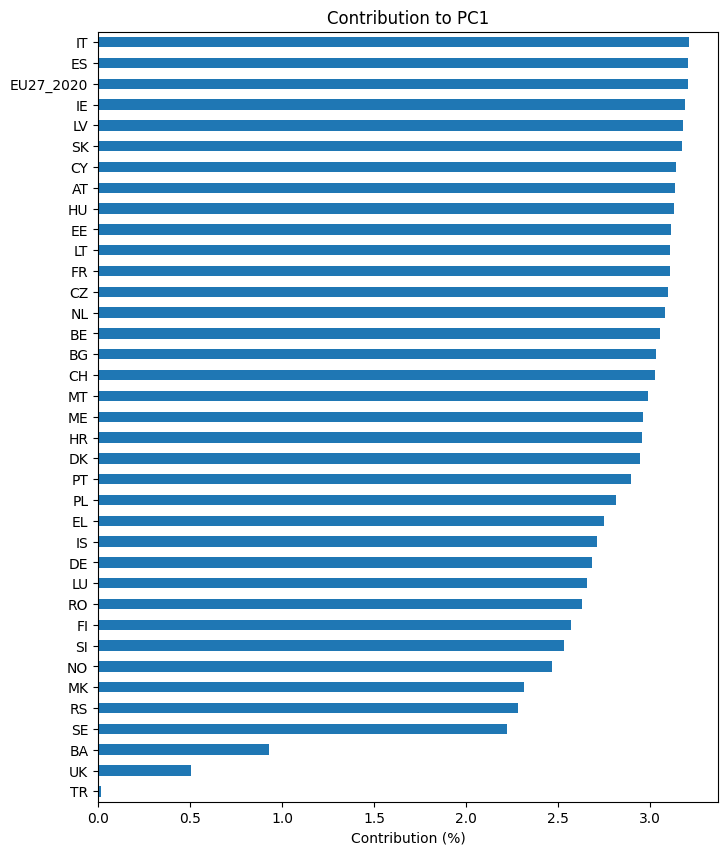

In [51]:
import matplotlib.pyplot as plt

contrib["PC1"].sort_values().plot(
    kind="barh",
    figsize=(8,10),
    title="Contribution to PC1"
)

plt.xlabel("Contribution (%)")
plt.show()

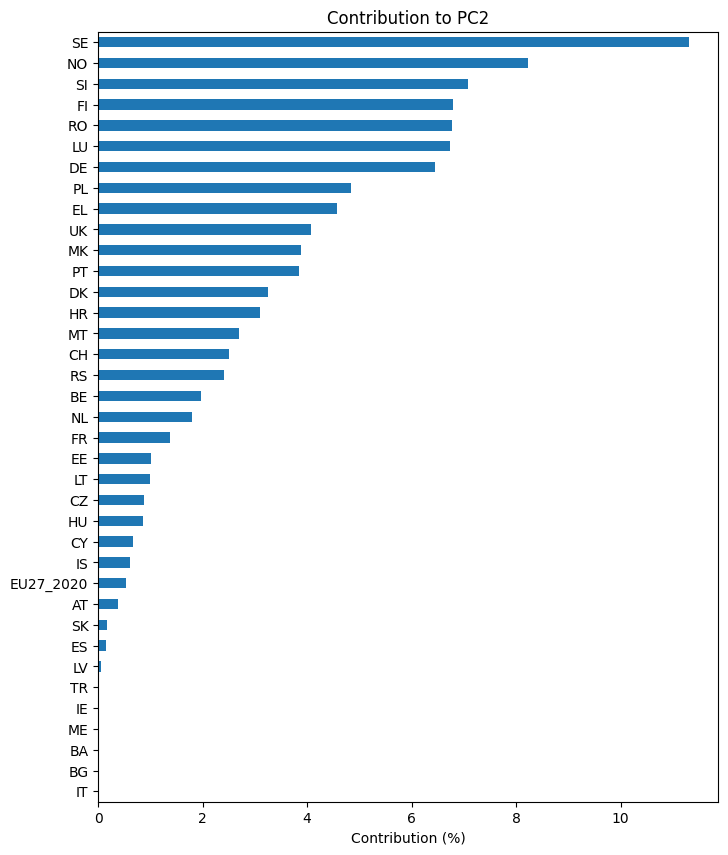

In [52]:
contrib["PC2"].sort_values().plot(
    kind="barh",
    figsize=(8,10),
    title="Contribution to PC2"
)

plt.xlabel("Contribution (%)")
plt.show()

## Loading calculation
We extracted and ranked the variable loadings of the first principal component (PC1) to identify which original variables contribute most strongly to it. The results show that the loadings of most countries are very similar, with a large number falling within the range of 0.16–0.18. This indicates that PC1 is not driven by a small subset of countries versus others, but rather reflects a pattern in which all countries tend to move together. In other words, although differences exist across national aviation industries, their dynamics over time exhibit a high degree of common fluctuation. The integrated nature of the European (and broader regional) aviation market leads EU member states and neighboring countries to share a common underlying trend. Moreover, almost all countries have positive loadings on PC1, implying that increases in PC1 are associated with simultaneous increases across nearly all country-level variables.

Notably, Bosnia and Herzegovina, the United Kingdom, and Turkey, which are not EU member states, display relatively small loadings on PC1. This suggests that their aviation development patterns are less tightly coupled with the EU single market and therefore contribute less to the dominant EU-wide factor captured by PC1. This finding further supports the interpretation that the EU single market fosters greater similarity in aviation industry dynamics among member states, whereas non-EU countries exhibit greater heterogeneity and uncertainty.

In [53]:
import pandas as pd

scores = pca.transform(air_scaled)


years = year_cols

ind_coord = pd.DataFrame(
    scores,
    index=years,
    columns=[f"Dim.{i+1}" for i in range(scores.shape[1])]
)

print(ind_coord)

          Dim.1     Dim.2     Dim.3     Dim.4     Dim.5     Dim.6     Dim.7  \
2013  -2.398530  2.146311 -1.627565  0.896962 -0.251186 -0.280999  0.234183   
2014  -1.561728  1.977064 -1.231280  0.682141 -0.195738 -0.082593  0.065089   
2015  -0.646519  1.901842 -0.442088  0.271857  0.064035  0.123857 -0.442520   
2016   0.649668  1.412787  0.572104 -0.373295  0.289290  0.577492 -0.097589   
2017   2.850881  0.963235  1.352939 -0.669072  0.061769  0.411203  0.224397   
2018   4.766262  0.524867  1.669097 -0.738455 -0.101182  0.021956  0.405376   
2019   5.689893  0.037663  1.316950 -0.436077 -0.294459 -0.954360 -0.417968   
2020 -11.817124 -0.972468  0.326528 -0.858742  1.251867 -0.444083  0.210603   
2021  -9.522967 -1.875885  1.111064  0.757803 -1.541311  0.237019 -0.100307   
2022   0.724642 -1.705709 -0.709895 -0.283088  0.856268  0.429876 -0.448281   
2023   4.642308 -2.106127 -2.346338 -1.943539 -0.678966 -0.006947  0.164319   
2024   6.623213 -2.303581  0.008484  2.693504  0.539

In [54]:
import numpy as np

cos2 = (scores ** 2) / np.sum(scores ** 2, axis=1, keepdims=True)

ind_cos2 = pd.DataFrame(
    cos2,
    index=years,
    columns=[f"Dim.{i+1}" for i in range(scores.shape[1])]
)

print(ind_cos2)

         Dim.1     Dim.2     Dim.3     Dim.4     Dim.5     Dim.6     Dim.7  \
2013  0.408848  0.327383  0.188256  0.057177  0.004484  0.005612  0.003897   
2014  0.289342  0.463705  0.179852  0.055201  0.004545  0.000809  0.000503   
2015  0.088049  0.761921  0.041170  0.015568  0.000864  0.003231  0.041250   
2016  0.121382  0.574017  0.094129  0.040075  0.024068  0.095910  0.002739   
2017  0.699335  0.079835  0.157501  0.038519  0.000328  0.014549  0.004333   
2018  0.854022  0.010356  0.104731  0.020500  0.000385  0.000018  0.006178   
2019  0.912131  0.000040  0.048864  0.005358  0.002443  0.025661  0.004922   
2020  0.974790  0.006601  0.000744  0.005148  0.010940  0.001377  0.000310   
2021  0.921079  0.035741  0.012538  0.005833  0.024129  0.000571  0.000102   
2022  0.099482  0.551198  0.095474  0.015182  0.138905  0.035009  0.038071   
2023  0.602279  0.123965  0.153855  0.105564  0.012883  0.000001  0.000755   
2024  0.772507  0.093448  0.000001  0.127762  0.005128  0.000019

## Individual Coordinates
Each year (2013–2024) is treated as an individual, and its position in the principal component space, as well as its contribution to each principal component, is calculated in order to analyze the temporal structure and evolution of the data. The results based on individual coordinates reveal a very clear time-related structure in the distribution of years within the principal component space. The first principal component (Dim.1) explains the vast majority of the variance in the data, and its scores exhibit pronounced stage-wise changes over time. Specifically, from 2013 to 2019, the scores on Dim.1 gradually increase from negative to positive values, reflecting an overall growth trend in aviation-related indicators during this period. However, in 2020 and 2021, the Dim.1 scores drop sharply to extreme negative values, deviating markedly from the previous trajectory and indicating a strong structural shock to the aviation industry. This abrupt break is highly consistent with the global impact of the COVID-19 pandemic on air transport activity. After 2022, the Dim.1 scores recover rapidly and continue to rise in 2023 and 2024, exceeding pre-pandemic levels and suggesting a rebound of the aviation industry following the short-term disruption. Therefore, the first principal component can be reasonably interpreted as a composite indicator capturing changes in the overall scale or activity level of the aviation industry over time.

In contrast, the second principal component (Dim.2) explains a much smaller proportion of the total variance and mainly reflects secondary structural differences beyond the overall trend captured by Dim.1. The results show that during the period from 2013 to 2018, most years take negative values on Dim.2, while from 2019 onwards the scores gradually move toward zero and even become positive, with a clear sign change after 2020. This indicates that Dim.2 distinguishes, to some extent, structural differences between the pre-pandemic and post-pandemic periods. However, given its limited explanatory power, this component should not be overinterpreted. The third and higher-order principal components display noticeable values only for a small number of years and account for very little variance overall, suggesting that they mainly capture localized fluctuations or random noise and contribute little to explaining the overall temporal structure.

ind<-get_pca_ind(pca_air)  

In [55]:
# eigenvalues
eigenvalues = pca.explained_variance_

# contribution
contrib = (scores ** 2) / eigenvalues
contrib = contrib / contrib.sum(axis=0) * 100

ind_contrib = pd.DataFrame(
    contrib,
    index=years,
    columns=[f"Dim.{i+1}" for i in range(scores.shape[1])]
)

print(ind_contrib)

          Dim.1      Dim.2      Dim.3      Dim.4      Dim.5      Dim.6  \
2013   1.561069  14.196390  14.405291   5.331480   1.103408   4.040398   
2014   0.661824  12.045748   8.244399   3.083528   0.670035   0.349061   
2015   0.113421  11.146571   1.062828   0.489756   0.071710   0.784977   
2016   0.114529   6.150999   1.779897   0.923429   1.463563  17.065023   
2017   2.205414   2.859284   9.954097   2.966502   0.066725   8.652197   
2018   6.164355   0.848969  15.149847   3.613658   0.179040   0.024668   
2019   8.784965   0.004371   9.431564   1.260158   1.516335  46.605727   
2020  37.892684   2.914360   0.579812   4.886804  27.406990  10.091219   
2021  24.608003  10.844381   6.713109   3.805502  41.545687   2.874620   
2022   0.142488   8.966071   2.740522   0.531057  12.822255   9.455859   
2023   5.847898  13.669776  29.938243  25.031445   8.061970   0.002470   
2024  11.903350  16.353080   0.000391  48.076680   5.092282   0.053783   

          Dim.7      Dim.8      Dim.9

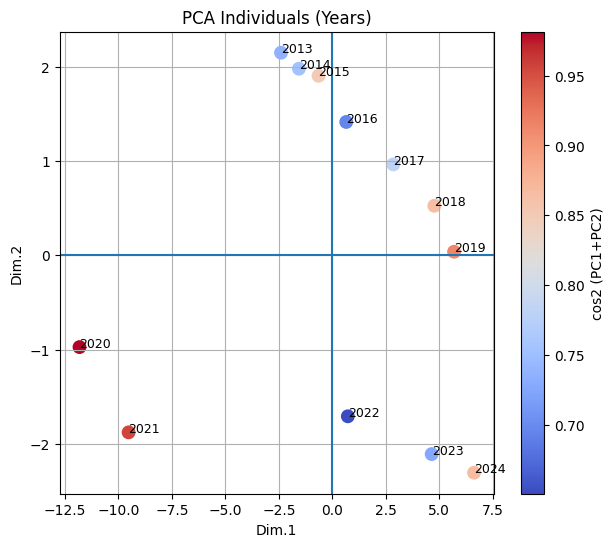

In [56]:
import matplotlib.pyplot as plt


cos2_PC12 = cos2[:, 0] + cos2[:, 1]

plt.figure(figsize=(7,6))

sc = plt.scatter(
    scores[:, 0],
    scores[:, 1],
    c=cos2_PC12,
    cmap="coolwarm",
    s=80
)


for i, year in enumerate(years):
    plt.text(scores[i, 0], scores[i, 1], year, fontsize=9)

plt.xlabel("Dim.1")
plt.ylabel("Dim.2")
plt.title("PCA Individuals (Years)")
plt.colorbar(sc, label="cos2 (PC1+PC2)")

plt.axhline(0)
plt.axvline(0)
plt.grid()

plt.show()

## Individual Contributions
Based on the individual contribution results, the first principal component is mainly defined by a small number of years, among which 2020 and 2021 contribute significantly more to PC1 than other years. This indicates that the orientation of the principal component is largely driven by these extreme years. It suggests that the aviation industry experienced a strong structural shock during this period, while the intermediate years contribute relatively little to the construction of the component and mainly reflect stable phases of the overall trend. From 2013 to 2019, the observations move gradually from the lower-left to the right in the PCA space, indicating a period of steady growth in the European aviation industry, which reached its peak in 2019. During 2020–2021, the data points shift abruptly to the far left, representing a strong negative deviation. This reflects the severe impact of the COVID-19 pandemic, during which changes in entry policies, widespread flight suspensions, and temporary airspace closures led to a rapid contraction of the aviation sector. From 2022 to 2024, the points move rapidly back to the right, showing a clear recovery that even exceeds pre-pandemic levels. This rebound may be attributed to pent-up travel demand following two to three years of restrictions, as well as policy measures implemented by the EU to revitalize the aviation industry. Overall, the first principal component primarily captures the long-term temporal evolution of the aviation industry and clearly identifies the structural shock occurring in 2020–2021. The second principal component appears to describe a secondary growth-related pattern: values are negative before the pandemic, possibly reflecting a smoother development phase, and become positive after the pandemic, potentially corresponding to a period of rapid expansion or contraction. However, this interpretation requires further validation and should be regarded only as a supplementary explanation. Finally, the cos²-based coloring confirms that the years associated with the pandemic shock and subsequent recovery are well represented by the first two principal components, indicating that these key periods are robustly and reliably captured by the PCA results.

## Summary & Business insight

The analysis leads to a clear business conclusion: under normal conditions, the European aviation market does not operate as a collection of independent national systems, but as a highly integrated and strongly synchronized regional market. Between 2013 and 2019, aviation activity across countries followed a highly consistent growth trajectory, indicating that demand, capacity allocation, and industry dynamics are primarily driven by macroeconomic conditions and the institutional framework of the EU single market. In operational terms, intra-Schengen aviation—where border controls and customs are absent—functions much like a domestic market, comparable to the internal aviation systems of China or the United States.

However, this integration is not uniform. Routes within the EU but outside the Schengen Area occupy an intermediate position between domestic and international markets. Their structure is comparable to mainland–Hong Kong/Macau routes in China: relatively integrated, yet still subject to certain boundary constraints. These routes are also more exposed to substitution from rail and road transport, leading to greater variability in demand and profitability compared to fully integrated intra-Schengen routes.

The results for 2020–2021 highlight a critical implication of this integration: while it enhances efficiency, it also amplifies systemic risk. In response to the COVID-19 shock, aviation activity across countries deviated simultaneously and sharply from prior trends, demonstrating how disruptions propagate rapidly across a tightly connected system. The strong rebound observed from 2022 onward reflects equally strong system-level resilience, driven by coordinated policy responses, restoration of cross-border networks, and the release of pent-up demand.

Structurally, the European aviation market is shaped by the interaction of multiple layers: regulatory boundaries (shared EU market rules), national boundaries (country-level differences), and operational boundaries (Schengen vs. non-Schengen divisions). This creates a system that is simultaneously integrated at the macro level while internally differentiated.

From a commercial and strategic perspective, these findings suggest that country-level analysis provides limited incremental value in understanding the EU aviation market. Instead, decision-making should prioritize system-wide cycles, macro demand conditions, and the transmission of external shocks. Airlines, airport operators, and investors should focus on market-level dynamics and cross-border coordination. In contrast, non-EU and peripheral markets exhibit weaker synchronization, implying higher uncertainty and risk premia, but also potential opportunities for differentiated strategies.

n a highly integrated aviation market, localized strategies are structurally constrained. Competitive advantage depends more on timing the overall market cycle and managing systemic shocks than on country-specific positioning.

While airlines may rely on national governments for financial support, serve as symbols of national identity, and base their operations around domestic hub airports, their strategic positioning in Europe should be fundamentally supranational. In practice, European carriers operate less as national airlines and more as participants in a unified EU market.

Crucially, competition is not primarily intra-EU but external, with global carriers representing the main competitive pressure. At the same time, aviation activity across EU countries moves in a highly synchronized manner, with market expansion and contraction occurring simultaneously.

As a result, national-level differentiation provides limited strategic advantage. The critical capability lies in aligning with EU-wide demand cycles and managing system-wide risks, rather than optimizing for individual country markets.